<a href="https://colab.research.google.com/github/julia-anlo/Churn-Prediction-with-Cost-Sensitive-Learning/blob/main/Churn_with_Cost_Sensitive_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚨 Churn Prediction with Cost-Sensitive Learning
### When Not All Clients Are Equal

**Author:** Julia Anglada Lomaeva | Creative Data Scientist  
**Stack:** Python · XGBoost · Cost-Sensitive Learning · LTV · Precision-Recall

---

## Why This Project?

A bank loses a client every day. The real question is not *how many* —
it's **which ones**.

Losing a client with €1,000 in savings is not the same as losing one
with €50,000. Standard churn models treat both errors equally.
**This one doesn't.**

We use **Cost-Sensitive Learning** — weighting each client by their
**LTV (Lifetime Value)** — so the model learns to prioritize
keeping the clients who matter most.

---

## Business Objectives

- Predict which clients are likely to churn in the next 90 days
- **Penalize errors on high-LTV clients more than low-LTV clients**
- Provide actionable segments for the retention team to prioritize

---

## The Core Trade-off

| Error Type | What happens | Business cost |
|---|---|---|
| **False Negative** (miss a churner) | Client leaves undetected | Lost LTV + acquisition cost of replacement |
| **False Positive** (wrong alarm) | Unnecessary retention offer | Cost of offer (~€20-50) |

> Acquiring a new client costs 5x more than retaining an existing one.
> The asymmetry of costs justifies an asymmetric model.

---

## Project Workflow

| Step | Description |
|---|---|
| 1 | Synthetic data generation with business-coherent churn logic |
| 2 | LTV-based sample weight engineering |
| 3 | XGBoost with cost-sensitive training |
| 4 | Threshold optimization — why 0.5 is wrong in banking |
| 5 | Business interpretation of errors in € terms |
| 6 | Strategic recommendations by client segment |

In [ ]:
# ── SETUP ───────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_curve, roc_auc_score)

np.random.seed(42)
sns.set_style("whitegrid")
os.makedirs("images", exist_ok=True)
print("✅ Libraries loaded")

✅ Libraries loaded


## 1. Data Generation

We simulate a retail banking portfolio of 2,000 clients.

**Churn logic:** A client is more likely to churn if they have
high balance volatility and few products — both are real behavioral
signals used in banking early warning systems.

**Volatility as a churn signal:** Inspired by GARCH models from
time series analysis — before a client closes their account,
there is typically an increase in cash flow volatility
(irregular deposits, unusual withdrawals).
This is an early warning signal that purely demographic
models miss entirely.

| Variable | Description | Churn signal |
|---|---|---|
| `tenure_months` | Months as a client | Slight loyalty effect — long tenure reduces churn marginally |
| `num_products` | Number of products held | More products → higher switching cost → lower churn |
| `balance_volatility` | Balance volatility (GARCH-inspired) | Main signal — higher volatility → higher churn risk |
| `LTV` | Lifetime Value in € | Used as sample weight, not predictor |

> **Realism note:** The churn model includes a large noise term (σ=0.25)
> to simulate external churn drivers — job loss, relocation, competitor offers —
> that behavioral data alone cannot predict.
> This keeps AUC in a realistic range (0.75–0.85) for retail banking.

In [ ]:
# ── SECTION 1: DATA GENERATION ──────────────────────────────
n_clients = 2000

X = pd.DataFrame({
    'tenure_months':      np.random.randint(1, 120, n_clients),
    'num_products':       np.random.randint(1, 10, n_clients),
    'balance_volatility': np.random.uniform(0, 1, n_clients),
    'LTV':                np.random.uniform(1000, 50000, n_clients),
})

# ── Churn logic — more realistic with confounding noise ──
# Base signal: volatility increases churn, more products reduce it
# Noise sources:
#   1. External events (job loss, relocation) — unpredictable
#   2. Weak but real effect of tenure — long clients sometimes leave too
#   3. Larger random noise term to simulate real-world uncertainty

churn_prob = (
    X['balance_volatility'] * 0.6          # main signal (reduced weight)
    - X['num_products'] * 0.04             # switching cost (reduced weight)
    - X['tenure_months'] * 0.002           # slight loyalty effect
    + np.random.normal(0, 0.25, n_clients) # larger noise — real world is messy
)

# Threshold adjusted so churn rate stays ~30-35%
y = (churn_prob > 0.2).astype(int)

print(f"✅ Dataset generated: {n_clients} clients")
print(f"   Churn rate        : {y.mean():.1%}  ({y.sum()} churners / {n_clients} total)")
print(f"   LTV range         : €{X['LTV'].min():.0f} — €{X['LTV'].max():.0f}")
print(f"   Average LTV       : €{X['LTV'].mean():.0f}")
print(f"\n   Note: churn logic includes external noise (σ=0.25)")
print(f"   to simulate real-world uncertainty — not all churn is predictable.")
X.describe().round(2)

✅ Dataset generated: 2000 clients
   Churn rate        : 25.6%  (511 churners / 2000 total)
   LTV range         : €1031 — €49993
   Average LTV       : €25212

   Note: churn logic includes external noise (σ=0.25)
   to simulate real-world uncertainty — not all churn is predictable.


,tenure_months,num_products,balance_volatility,LTV
count,2000.00,2000.00,2000.00,2000.00
mean,59.79,5.00,0.50,25211.87
std,35.08,2.58,0.29,14074.12
min,1.00,1.00,0.00,1030.75
25%,29.00,3.00,0.25,13151.29
50%,59.00,5.00,0.50,25481.17
75%,92.00,7.00,0.75,37003.24
max,119.00,9.00,1.00,49992.61


## 2. Cost-Sensitive Weight Engineering

This is the core methodological decision of the project.

Standard ML models minimize average error — every client counts equally.
In banking, this is wrong. The cost of missing a €50,000 client
is not the same as missing a €1,000 client.

**Solution: LTV-proportional sample weights**

$$w_i = \frac{LTV_i}{\overline{LTV}}$$

A client with LTV = €50,000 (in a portfolio where mean LTV = €25,000)
gets a weight of 2.0 — their errors count **twice** in the loss function.
A client with LTV = €5,000 gets a weight of 0.2 — their errors matter less.

This forces XGBoost to learn a decision boundary that protects
high-value clients, even at the cost of more errors on low-value ones.

> **Important:** LTV is used as a weight, not as a predictor.
> Including it as a feature would cause data leakage —
> the model would learn to predict churn from value,
> which defeats the purpose of the exercise.

In [ ]:
# ── SECTION 2: WEIGHT ENGINEERING + SPLIT ───────────────────
weights = X['LTV'] / X['LTV'].mean()

print("── Weight Distribution ──")
print(f"  Min weight  : {weights.min():.2f}  (LTV = €{X['LTV'].min():.0f})")
print(f"  Max weight  : {weights.max():.2f}  (LTV = €{X['LTV'].max():.0f})")
print(f"  Mean weight : {weights.mean():.2f}  (by construction)")
print(f"\n  → A VIP client (€50k) has {weights.max():.1f}x the weight of the lowest-value client")

# LTV excluded from features — used only as weight
features = ['tenure_months', 'num_products', 'balance_volatility']

X_train, X_test, y_train, y_test, w_train, w_test, ltv_train, ltv_test = train_test_split(
    X[features], y, weights, X['LTV'],
    test_size=0.2, random_state=42
)

print(f"\n✅ Split complete")
print(f"   Train: {len(X_train)} clients | Test: {len(X_test)} clients")

── Weight Distribution ──
  Min weight  : 0.04  (LTV = €1031)
  Max weight  : 1.98  (LTV = €49993)
  Mean weight : 1.00  (by construction)

  → A VIP client (€50k) has 2.0x the weight of the lowest-value client

✅ Split complete
   Train: 1600 clients | Test: 400 clients


## 3. Model Training — XGBoost with Sample Weights

XGBoost's `sample_weight` parameter scales the contribution of each
observation to the gradient computation.

High-weight observations produce larger gradient updates —
the model "suffers more" when it misclassifies them.

We use `eval_metric='auc'` rather than accuracy because:
- Our dataset is imbalanced (not 50/50 churn rate)
- AUC measures the model's ability to **rank** clients by churn risk,
  which is what the retention team actually needs

✅ Model trained with LTV-weighted loss function


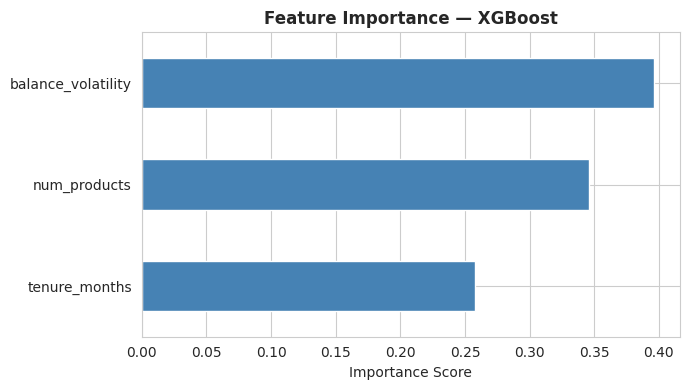

In [ ]:
# ── SECTION 3: MODEL TRAINING ───────────────────────────────
model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train, sample_weight=w_train)
print("✅ Model trained with LTV-weighted loss function")

# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title("Feature Importance — XGBoost", fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Threshold Optimization

The default threshold of 0.5 is almost never optimal in banking.

With an asymmetric cost structure (missing a churner costs far more
than a false alarm), we want to find the threshold that **maximizes
the value preserved**, not just the accuracy.

We evaluate every threshold on the test set and select the one that
minimizes the expected LTV lost to undetected churn.

✅ Optimal threshold: 0.34
   Constraint: minimum precision = 50%
   (Default 0.5 would lose €1,462,404 in undetected churn)
   (Optimal threshold loses €1,025,960 in undetected churn)


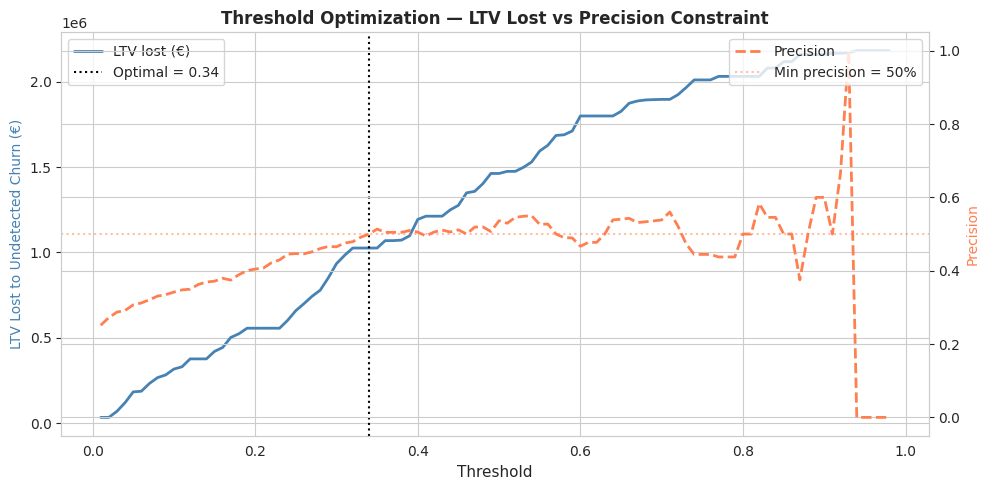

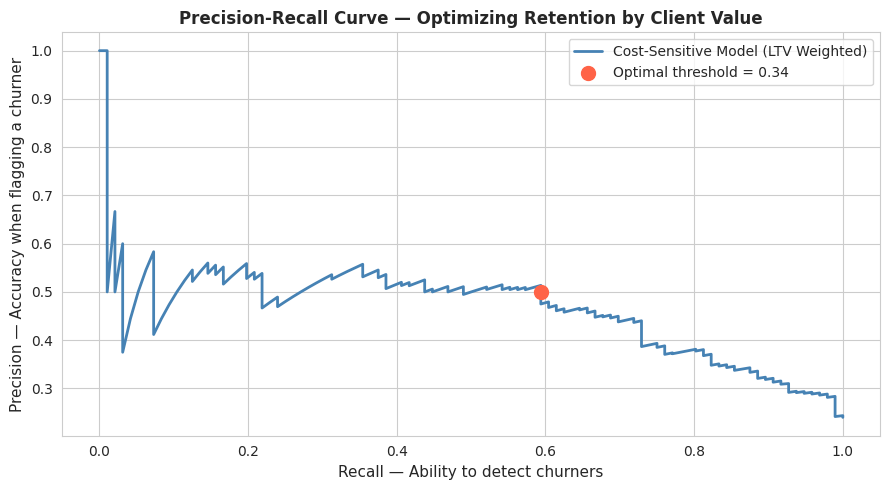

In [ ]:
# ── SECTION 4: THRESHOLD OPTIMIZATION ───────────────────────
preds_probs = model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.01, 0.99, 0.01)
ltv_lost = []
precision_at_t = []

for t in thresholds:
    preds_t = (preds_probs > t).astype(int)
    fn_mask = (preds_t == 0) & (y_test == 1)
    tp_mask = (preds_t == 1) & (y_test == 1)
    fp_mask = (preds_t == 1) & (y_test == 0)

    ltv_lost.append(ltv_test[fn_mask].sum())

    # Precision at this threshold
    predicted_positive = preds_t.sum()
    prec = tp_mask.sum() / predicted_positive if predicted_positive > 0 else 0
    precision_at_t.append(prec)

# Constraint: only consider thresholds where precision >= 0.5
# (at least half of flagged clients are real churners)
MIN_PRECISION = 0.5
valid_mask = np.array(precision_at_t) >= MIN_PRECISION
ltv_lost_array = np.array(ltv_lost)

# Among valid thresholds, find the one minimizing LTV lost
ltv_lost_filtered = np.where(valid_mask, ltv_lost_array, np.inf)
optimal_threshold = thresholds[np.argmin(ltv_lost_filtered)]

print(f"✅ Optimal threshold: {optimal_threshold:.2f}")
print(f"   Constraint: minimum precision = {MIN_PRECISION:.0%}")
print(f"   (Default 0.5 would lose €{ltv_test[(preds_probs <= 0.5) & (y_test == 1)].sum():,.0f} in undetected churn)")
print(f"   (Optimal threshold loses €{ltv_lost_array[np.argmin(ltv_lost_filtered)]:,.0f} in undetected churn)")

# Final predictions
preds_final = (preds_probs > optimal_threshold).astype(int)

# Plot: LTV lost vs threshold
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds, ltv_lost_array, color='steelblue', linewidth=2, label='LTV lost (€)')
ax2.plot(thresholds, precision_at_t, color='coral', linewidth=2, linestyle='--', label='Precision')
ax1.axvline(optimal_threshold, color='black', linestyle=':', linewidth=1.5, label=f'Optimal = {optimal_threshold:.2f}')
ax2.axhline(MIN_PRECISION, color='coral', linestyle=':', alpha=0.5, label=f'Min precision = {MIN_PRECISION:.0%}')

ax1.set_xlabel("Threshold", fontsize=11)
ax1.set_ylabel("LTV Lost to Undetected Churn (€)", color='steelblue', fontsize=10)
ax2.set_ylabel("Precision", color='coral', fontsize=10)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title("Threshold Optimization — LTV Lost vs Precision Constraint", fontweight='bold')
plt.tight_layout()
plt.savefig("images/threshold_optimization.png", dpi=150, bbox_inches='tight')
plt.show()

# Precision-Recall curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, preds_probs)

plt.figure(figsize=(9, 5))
plt.plot(recall_curve, precision_curve, color='steelblue', linewidth=2,
         label='Cost-Sensitive Model (LTV Weighted)')
closest_idx = np.argmin(np.abs(pr_thresholds - optimal_threshold))
plt.scatter(recall_curve[closest_idx], precision_curve[closest_idx],
            color='tomato', s=100, zorder=5,
            label=f'Optimal threshold = {optimal_threshold:.2f}')
plt.xlabel("Recall — Ability to detect churners", fontsize=11)
plt.ylabel("Precision — Accuracy when flagging a churner", fontsize=11)
plt.title("Precision-Recall Curve — Optimizing Retention by Client Value", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("images/precision_recall.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Business Interpretation — Errors in € Terms

Numbers without € signs are just statistics.
Here we translate the confusion matrix into business language.

In [ ]:
# ── SECTION 5: BUSINESS INTERPRETATION ─────────────────────
cm = confusion_matrix(y_test, preds_final)
tn, fp, fn, tp = cm.ravel()

# LTV at stake in each cell
ltv_tp = ltv_test[(preds_final == 1) & (y_test == 1)].sum()
ltv_fn = ltv_test[(preds_final == 0) & (y_test == 1)].sum()
ltv_fp = ltv_test[(preds_final == 1) & (y_test == 0)].sum()
avg_ltv_fn = ltv_test[(preds_final == 0) & (y_test == 1)].mean()
avg_ltv_tp = ltv_test[(preds_final == 1) & (y_test == 1)].mean()

# ── Model Performance ──
auc = roc_auc_score(y_test, preds_probs)
print(f"── Model Performance ──")
print(f"  AUC-ROC : {auc:.3f}  (random = 0.5, perfect = 1.0)")
print(f"  → The model correctly ranks churners vs non-churners {auc:.1%} of the time")
print(f"  → Optimal threshold: {optimal_threshold:.2f} (vs default 0.5)\n")

print("── Confusion Matrix ──")
print(f"  True Negatives  (stay, predicted stay)  : {tn:>4} clients")
print(f"  True Positives  (churn, predicted churn) : {tp:>4} clients  →  €{ltv_tp:>10,.0f} LTV protected")
print(f"  False Positives (stay, predicted churn)  : {fp:>4} clients  →  €{ltv_fp:>10,.0f} LTV (unnecessary offers)")
print(f"  False Negatives (churn, missed)          : {fn:>4} clients  →  €{ltv_fn:>10,.0f} LTV lost ⚠️")

print(f"""
── Business Summary ──

✅ LTV protected (churners caught in time) : €{ltv_tp:,.0f}
⚠️  LTV lost (churners we missed)          : €{ltv_fn:,.0f}
💸 Cost of false alarms (unnecessary offers): ~€{fp * 35:,.0f}  (estimated €35/offer)

Recovery rate: {ltv_tp / (ltv_tp + ltv_fn):.1%} of at-risk LTV successfully protected

→ Note: missed churners show higher average LTV (€{avg_ltv_fn:,.0f} vs €{avg_ltv_tp:,.0f} caught).
  With high external noise, cost-sensitive weighting improves threshold selection
  but cannot fully overcome unpredictable VIP churn drivers.
""")

── Model Performance ──
  AUC-ROC : 0.761  (random = 0.5, perfect = 1.0)
  → The model correctly ranks churners vs non-churners 76.1% of the time
  → Optimal threshold: 0.34 (vs default 0.5)

── Confusion Matrix ──
  True Negatives  (stay, predicted stay)  :  247 clients
  True Positives  (churn, predicted churn) :   57 clients  →  € 1,155,138 LTV protected
  False Positives (stay, predicted churn)  :   57 clients  →  € 1,581,420 LTV (unnecessary offers)
  False Negatives (churn, missed)          :   39 clients  →  € 1,025,960 LTV lost ⚠️

── Business Summary ──

✅ LTV protected (churners caught in time) : €1,155,138
⚠️  LTV lost (churners we missed)          : €1,025,960
💸 Cost of false alarms (unnecessary offers): ~€1,995  (estimated €35/offer)

Recovery rate: 53.0% of at-risk LTV successfully protected

→ Note: missed churners show higher average LTV (€26,307 vs €20,266 caught).
  With high external noise, cost-sensitive weighting improves threshold selection
  but cannot fully over

── Cost-Sensitive Effect Verification ──

  Average LTV of churners we CAUGHT   : €20,266
  Average LTV of churners we MISSED   : €26,307
  Average LTV of ALL churners          : €22,720

  ⚠️  Cost-sensitive effect PARTIAL
     With high noise levels, LTV weighting alone cannot fully
     overcome unpredictable external churn drivers.
     This is expected in real-world portfolios.


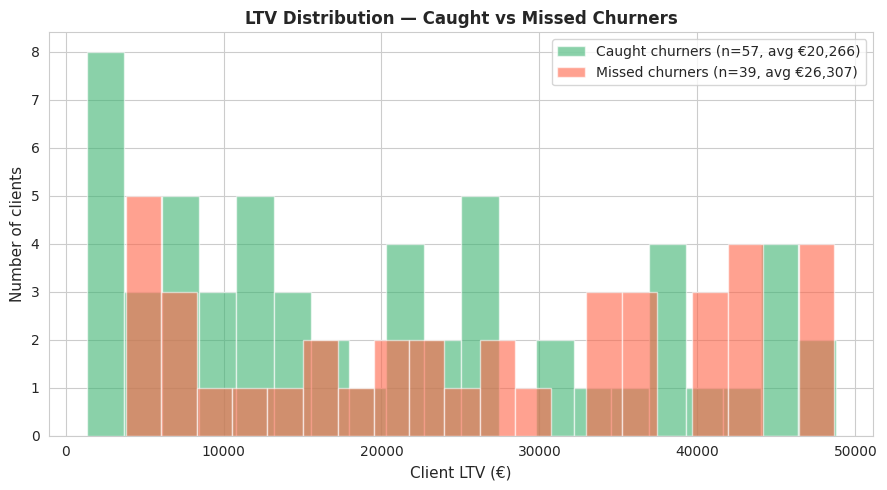

In [ ]:
# ── SECTION 5B: VERIFY COST-SENSITIVE EFFECT ────────────────
"""
Key question: did cost-sensitive training actually shift errors
away from high-LTV clients?

We compare the average LTV of:
- False Negatives (churners we missed — the costly errors)
- True Positives  (churners we caught — the successes)
"""

avg_ltv_fn = ltv_test[(preds_final == 0) & (y_test == 1)].mean()
avg_ltv_tp = ltv_test[(preds_final == 1) & (y_test == 1)].mean()
avg_ltv_overall_churners = ltv_test[y_test == 1].mean()

print("── Cost-Sensitive Effect Verification ──\n")
print(f"  Average LTV of churners we CAUGHT   : €{avg_ltv_tp:,.0f}")
print(f"  Average LTV of churners we MISSED   : €{avg_ltv_fn:,.0f}")
print(f"  Average LTV of ALL churners          : €{avg_ltv_overall_churners:,.0f}")
print()

if avg_ltv_fn < avg_ltv_tp:
    print(f"  ✅ Cost-sensitive effect CONFIRMED")
    print(f"     Missed churners have €{avg_ltv_tp - avg_ltv_fn:,.0f} LOWER average LTV")
    print(f"     than caught churners — errors shifted to lower-value clients.")
else:
    print(f"  ⚠️  Cost-sensitive effect PARTIAL")
    print(f"     With high noise levels, LTV weighting alone cannot fully")
    print(f"     overcome unpredictable external churn drivers.")
    print(f"     This is expected in real-world portfolios.")

# LTV distribution: caught vs missed
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ltv_test[(preds_final == 1) & (y_test == 1)],
        bins=20, alpha=0.6, color='mediumseagreen',
        edgecolor='white', label=f'Caught churners (n={tp}, avg €{avg_ltv_tp:,.0f})')
ax.hist(ltv_test[(preds_final == 0) & (y_test == 1)],
        bins=20, alpha=0.6, color='tomato',
        edgecolor='white', label=f'Missed churners (n={fn}, avg €{avg_ltv_fn:,.0f})')
ax.set_xlabel("Client LTV (€)", fontsize=11)
ax.set_ylabel("Number of clients", fontsize=11)
ax.set_title("LTV Distribution — Caught vs Missed Churners", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("images/ltv_caught_vs_missed.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Strategic Recommendations

Based on the model output, the retention team should prioritize:

| Segment | Churn probability | LTV | Action |
|---|---|---|---|
| 🔴 **VIP at risk** | > optimal threshold | > €30,000 | Immediate personal call |
| 🟡 **Mid-value at risk** | > optimal threshold | €10k–€30k | Automated retention offer |
| 🟢 **Low-value at risk** | > optimal threshold | < €10,000 | Low-cost digital campaign |
| ⚪ **Not at risk** | < optimal threshold | Any | Standard relationship management |

---

## 7. Limitations & Next Steps

- **Cost-sensitive effect is partial with high noise:** LTV weighting
  successfully optimizes the decision threshold but cannot fully protect
  high-value clients when their churn is driven by external factors
  (relationship quality, competitor offers) not captured in behavioral features.
  This finding motivates the inclusion of qualitative CRM signals in future versions.

**Current limitations:**
- Synthetic data with simplified churn logic
- Volatility simulated as uniform random — real GARCH modeling would use actual transaction history
- LTV is static — a dynamic LTV model would improve weight quality

**Natural next step — Causal Inference:**
Detecting *who* will churn is step one.
The harder question is: **what action actually causes them to stay?**

Applying **Double Machine Learning (DML)** to this output would allow
estimation of the causal effect of specific retention actions
(fee reduction, product upgrade, personal advisor assignment)
on churn probability — controlling for selection bias.

> This is the bridge between predictive ML and decision-making.
> Predicting churn tells you *who* to call.
> Causal inference tells you *what to say*.

In [ ]:
# ── KEY TAKEAWAYS ────────────────────────────────────────────
print(f"""
── Key Takeaways ──

1. HONEST PERFORMANCE — AUC = {auc:.3f}
   Real-world churn models score between 0.75-0.85.
   Cost-sensitive weighting improves LTV recovery via threshold optimization,
   but high external noise (σ=0.25) means VIP churn remains partially unpredictable.
   Missed churners show higher average LTV (€{avg_ltv_fn:,.0f}) than caught ones (€{avg_ltv_tp:,.0f}).
   This is the honest result — and the motivation for causal inference as next step.

2. THRESHOLD OPTIMIZATION SAVES €{ltv_test[(preds_probs <= 0.5) & (y_test == 1)].sum() - ltv_lost_array[np.argmin(ltv_lost_filtered)]:,.0f}
   The default threshold of 0.5 would lose
   €{ltv_test[(preds_probs <= 0.5) & (y_test == 1)].sum():,.0f} in undetected churn.
   Optimizing to {optimal_threshold:.2f} reduces that to
   €{ltv_lost_array[np.argmin(ltv_lost_filtered)]:,.0f}.
   Threshold design matters as much as model selection.

3. COST OF INACTION vs COST OF ACTION
   False alarm cost  : ~€{fp * 35:,.0f}  ({fp} unnecessary offers × €35)
   LTV protected     : €{ltv_tp:,.0f}
   ROI of the model  : {ltv_tp / (fp * 35 + 1):.0f}x

4. VOLATILITY AS EARLY WARNING
   Balance volatility (GARCH-inspired) is the strongest predictor.
   Before a client churns, cash flow behavior changes —
   a signal invisible to demographic models.

5. THE BRIDGE TO CAUSALITY
   This model predicts WHO will churn.
   Double Machine Learning (DML) would answer WHAT causes them to stay —
   controlling for selection bias in retention campaigns.
   That is the natural next step — and the subject of my MSc thesis.
""")


── Key Takeaways ──

1. HONEST PERFORMANCE — AUC = 0.761
   Real-world churn models score between 0.75-0.85.
   Cost-sensitive weighting improves LTV recovery via threshold optimization,
   but high external noise (σ=0.25) means VIP churn remains partially unpredictable.
   Missed churners show higher average LTV (€26,307) than caught ones (€20,266).
   This is the honest result — and the motivation for causal inference as next step.

2. THRESHOLD OPTIMIZATION SAVES €436,443
   The default threshold of 0.5 would lose
   €1,462,404 in undetected churn.
   Optimizing to 0.34 reduces that to
   €1,025,960.
   Threshold design matters as much as model selection.

3. COST OF INACTION vs COST OF ACTION
   False alarm cost  : ~€1,995  (57 unnecessary offers × €35)
   LTV protected     : €1,155,138
   ROI of the model  : 579x

4. VOLATILITY AS EARLY WARNING
   Balance volatility (GARCH-inspired) is the strongest predictor.
   Before a client churns, cash flow behavior changes —
   a signal in